In [215]:
import pandas as pd
import sqlite3
connection = sqlite3.connect('../../data/checking-logs.sqlite')
query = '''
SELECT 
    DATE(timestamp) as date,     
    CASE
        WHEN time("timestamp") BETWEEN '00:00:00' AND '03:59:59'
            THEN 'night'
        WHEN time("timestamp") BETWEEN '04:00:00' AND '09:59:59'
            THEN 'morning'
        WHEN time("timestamp") BETWEEN '10:00:00' AND '16:59:59'
            THEN 'afternoon'
        WHEN time("timestamp") BETWEEN '17:00:00' AND '23:59:59'
            THEN 'evening'
    END AS daytime
FROM checker
WHERE uid LIKE 'user%'
ORDER BY date
'''
df = pd.read_sql(query, connection)
pd.read_sql(query, connection)

,date,daytime
0,2020-04-17,morning
1,2020-04-17,morning
2,2020-04-17,morning
3,2020-04-17,morning
4,2020-04-17,morning
...,...,...
3202,2020-05-21,evening
3203,2020-05-21,evening
3204,2020-05-21,evening
3205,2020-05-21,evening


In [216]:
df

,date,daytime
0,2020-04-17,morning
1,2020-04-17,morning
2,2020-04-17,morning
3,2020-04-17,morning
4,2020-04-17,morning
...,...,...
3202,2020-05-21,evening
3203,2020-05-21,evening
3204,2020-05-21,evening
3205,2020-05-21,evening


In [217]:
result = df.pivot_table(index='date', 
                        columns='daytime', 
                        aggfunc='size', 
                        fill_value=0)
result = result[['night', 'morning','afternoon','evening']]

In [218]:
result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 2020-04-17 to 2020-05-21
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   night      35 non-null     int64
 1   morning    35 non-null     int64
 2   afternoon  35 non-null     int64
 3   evening    35 non-null     int64
dtypes: int64(4)
memory usage: 1.4+ KB


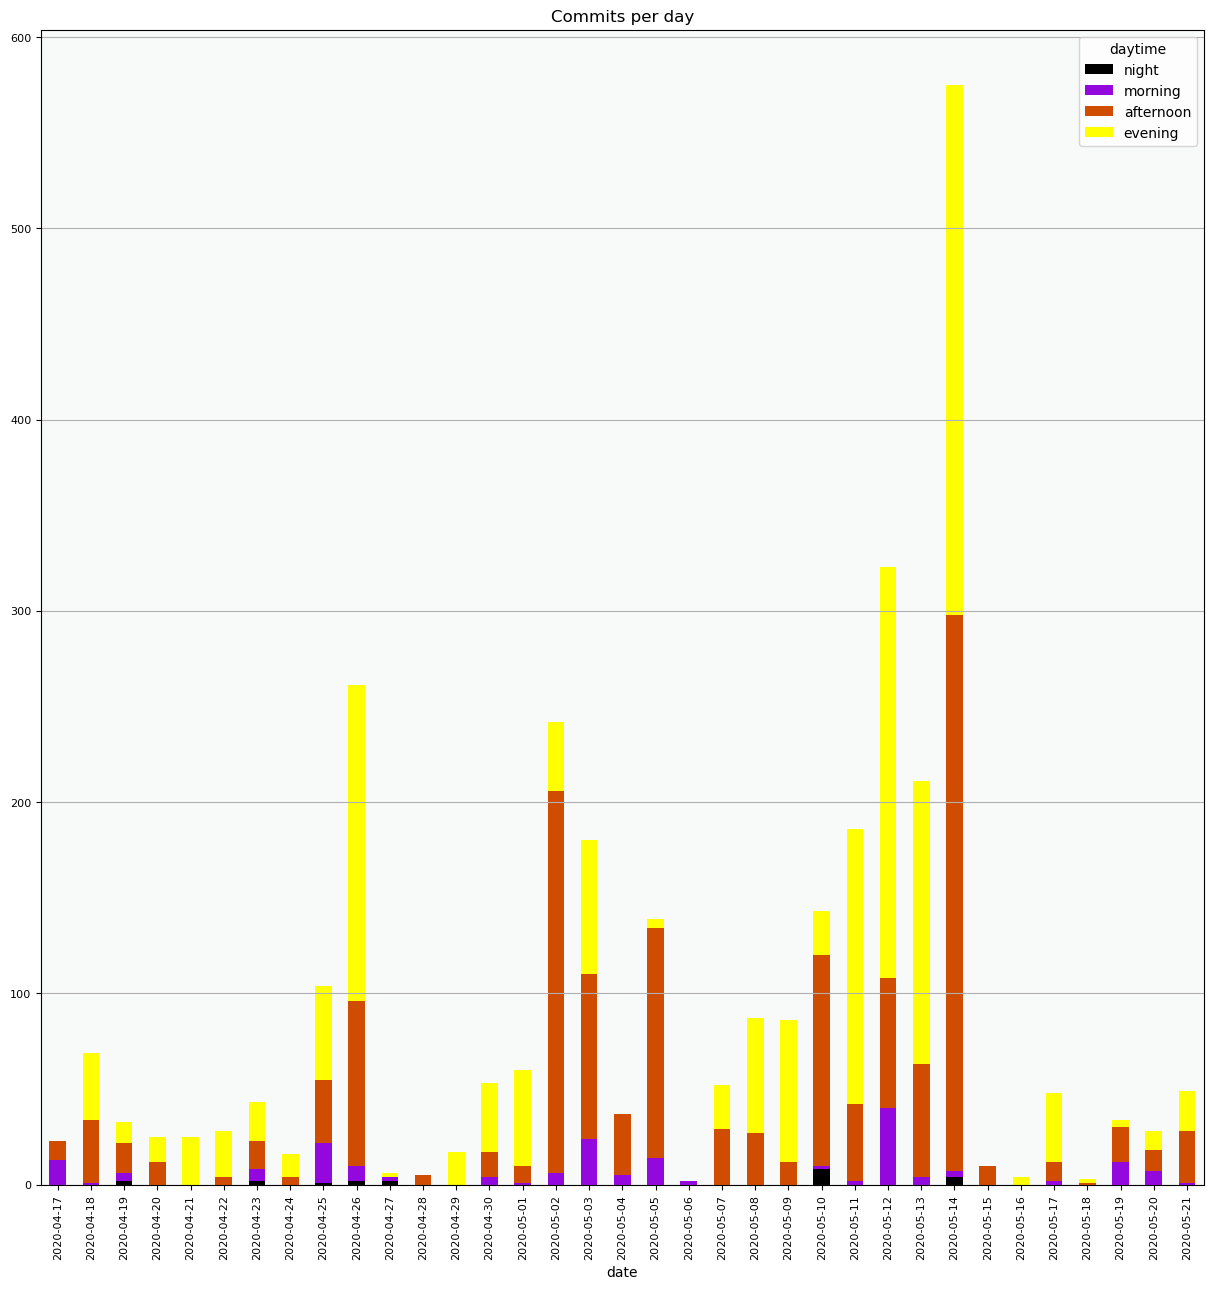

In [219]:
ax = result.plot(kind='bar', stacked=True, figsize=(15,15), fontsize=8, colormap='gnuplot', legend=True)
ax.set_title('Commits per day')
ax.set_xlabel('date')
ax.tick_params(axis='x', rotation=90)
ax.grid(axis='y')
ax.set_facecolor('#F8F9F9')

## When do our users usually commit the labs?

In [220]:
df['daytime'].value_counts()

daytime
evening      1611
afternoon    1391
morning       184
night          21
Name: count, dtype: int64

Evening and afternoon

## Which day has: the most number of commits and at the same time, the number of commits in the evening is higher than in the afternoon?

In [221]:
result[result['evening'] > result['afternoon']].sum(axis=1).idxmax()

'2020-05-12'

In [222]:
connection.close()